# Week 7 Coding Practice: PCA vs. LDA — Two Views of the Same Data

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/obscrivn/DataScience-book/blob/main/module07/week7_pca_lda_practice.ipynb)

**Estimated time:** 40–50 minutes
**Format:** worked examples, learning checkpoints (not graded), and a short PCA-vs-LDA comparison

Principal Component Analysis (PCA) and Linear Discriminant Analysis (LDA) are both dimensionality-reduction methods, but they answer different questions. PCA is unsupervised: it finds directions of maximum variance without looking at class labels. LDA is supervised: it finds directions that best separate known classes.

In this notebook you will fit both methods on the same dataset, decide how many PCA components to retain, interpret PCA loadings, see how LDA differs from PCA when the same data is given class labels, and critique an AI-generated interpretation of your own PCA output.

These checkpoints are learning checkpoints, not graded checkpoints. They are meant to help you pause, inspect your results, and explain your reasoning — not to produce a specific "correct" answer.


## Learning objectives

By the end of this activity, you should be able to:

1. judge whether standardizing features is appropriate before running PCA;
2. fit PCA and read eigenvalues, explained variance, and cumulative explained variance;
3. use a scree plot to reason about how many components to retain;
4. use loadings to interpret principal components, while recognizing the limits of that interpretation;
5. fit LDA on the same data and explain how it differs from PCA; and
6. critique an AI-generated interpretation of PCA output using evidence from your own results.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

sns.set_theme(style="whitegrid", context="notebook")

wine = load_wine()
X = wine.data
y = wine.target
feature_names = list(wine.feature_names)
class_names = list(wine.target_names)

df = pd.DataFrame(X, columns=feature_names)
df["cultivar"] = pd.Categorical.from_codes(y, categories=class_names)
df.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,cultivar
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


## 1. Inspect the data and decide whether to scale

We have 13 numeric chemical-composition measurements for 178 wine samples grown from three cultivars. Before running PCA, look at the scale of each feature.

Before running the next cell, think briefly:

- Which features are measured on much larger numeric scales than others?
- If we skip standardization, which features would dominate the PCA calculation simply because of their scale?


In [2]:
feature_ranges = df[feature_names].agg(["min", "max"]).T
feature_ranges["range"] = feature_ranges["max"] - feature_ranges["min"]
feature_ranges.sort_values("range", ascending=False)


,min,max,range
proline,278.00,1680.00,1402.00
magnesium,70.00,162.00,92.00
alcalinity_of_ash,10.60,30.00,19.40
color_intensity,1.28,13.00,11.72
malic_acid,0.74,5.80,5.06
flavanoids,0.34,5.08,4.74
alcohol,11.03,14.83,3.80
proanthocyanins,0.41,3.58,3.17
total_phenols,0.98,3.88,2.90
od280/od315_of_diluted_wines,1.27,4.00,2.73


### Checkpoint 1: PCA preparation

Examine:
- the features you are using (all 13 numeric chemical measurements)
- whether scaling is appropriate here
- a brief (1–2 sentence) justification

Write your answer in this cell.


## 2. Standardize the features and fit PCA

Now standardize the features and fit PCA using all available components so we can see how much variance each one explains.


In [3]:
X_scaled = StandardScaler().fit_transform(X)

pca = PCA().fit(X_scaled)
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print("Explained variance ratio (first 5 components):", np.round(explained[:5], 3))
print("Cumulative explained variance (first 5 components):", np.round(cumulative[:5], 3))


Explained variance ratio (first 5 components): [0.362 0.192 0.111 0.071 0.066]
Cumulative explained variance (first 5 components): [0.362 0.554 0.665 0.736 0.802]


## 3. Scree plot and choosing the number of components

A scree plot shows the proportion of variance explained by each component. Use it, together with the cumulative explained variance, to reason about how many components are worth keeping.

Before running the next cell, think briefly:

- Do you expect the "elbow" in the scree plot to be obvious or ambiguous for this dataset?
- Why might the right number of components depend on what you plan to do with them (visualization vs. compression vs. modeling)?


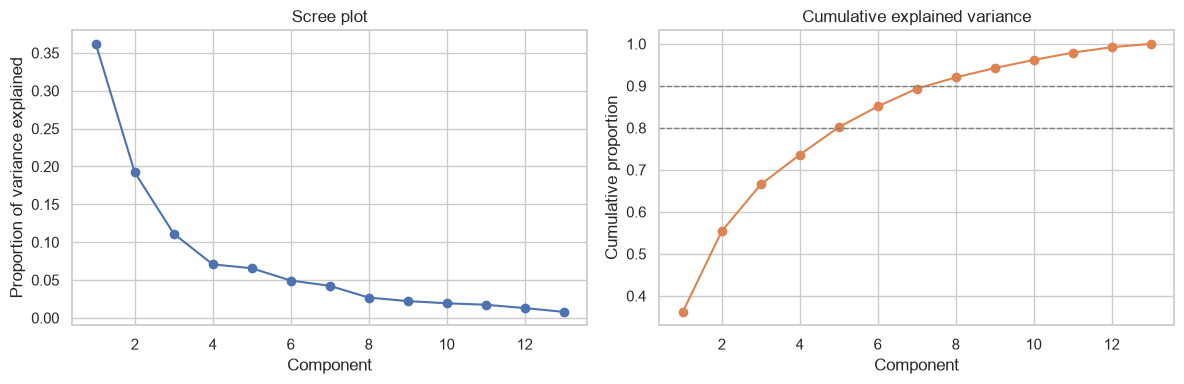

2 components explain 55.4% of the variance.
5 components are needed to reach 80% (80.2%).
8 components are needed to reach 90% (92.0%).


In [4]:
n_components = np.arange(1, len(explained) + 1)
n_for_80 = int(np.argmax(cumulative >= 0.80) + 1)
n_for_90 = int(np.argmax(cumulative >= 0.90) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(n_components, explained, marker="o")
axes[0].set_title("Scree plot")
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Proportion of variance explained")

axes[1].plot(n_components, cumulative, marker="o", color="C1")
axes[1].axhline(0.80, color="gray", linestyle="--", linewidth=1)
axes[1].axhline(0.90, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Cumulative explained variance")
axes[1].set_xlabel("Component")
axes[1].set_ylabel("Cumulative proportion")
plt.tight_layout()
plt.show()

print(f"2 components explain {cumulative[1]*100:.1f}% of the variance.")
print(f"{n_for_80} components are needed to reach 80% ({cumulative[n_for_80-1]*100:.1f}%).")
print(f"{n_for_90} components are needed to reach 90% ({cumulative[n_for_90-1]*100:.1f}%).")


### Checkpoint 2: Dimensionality decision

Examine:
- the scree plot
- the cumulative explained variance
- the possible numbers of retained components (2, the number needed for ~80%, and the number needed for ~90%)
- a short justification for which choice you would make and why

Write your answer in this cell.


## 4. Loadings and interpretation

Loadings describe how strongly each original feature contributes to a component. Examine the loadings table below for PC1 and PC2.


In [5]:
loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=feature_names,
    columns=["PC1 loading", "PC2 loading"],
)
loadings.sort_values("PC1 loading", ascending=False)


,PC1 loading,PC2 loading
flavanoids,0.422934,-0.003360
total_phenols,0.394661,0.065040
od280/od315_of_diluted_wines,0.376167,-0.164496
proanthocyanins,0.313429,0.039302
hue,0.296715,-0.279235
proline,0.286752,0.364903
alcohol,0.144329,0.483652
magnesium,0.141992,0.299634
ash,-0.002051,0.316069
color_intensity,-0.088617,0.529996


### Checkpoint 3: Interpretation

Examine:
- the component loadings above
- which variables contribute most strongly to PC1 and to PC2
- the limits of assigning real-world meaning to a principal component (a component is a mathematical summary, not automatically a natural category)

Write your answer in this cell.


## 5. Visualize the observations in PCA space

Transform the data onto the first two principal components and visualize it. Note that PCA did not use the cultivar labels to create these axes — we are only using them afterward to color the plot.


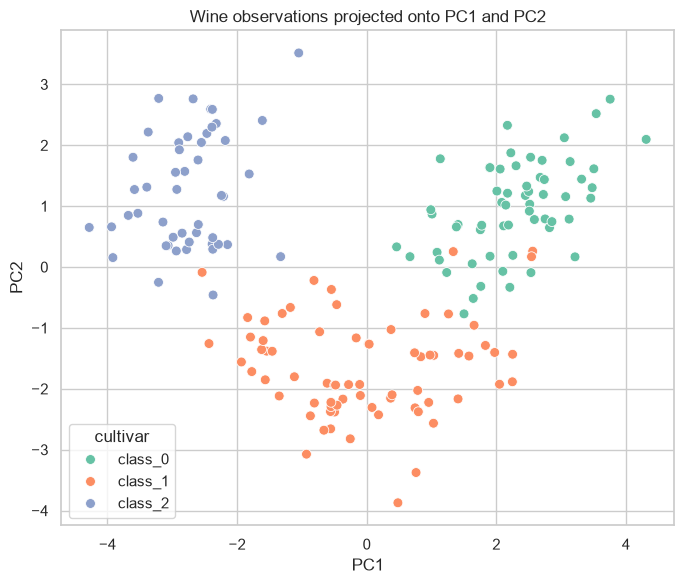

In [6]:
pca_2 = PCA(n_components=2).fit(X_scaled)
scores = pca_2.transform(X_scaled)
scores_df = pd.DataFrame(scores, columns=["PC1", "PC2"])
scores_df["cultivar"] = df["cultivar"]

plt.figure(figsize=(7, 6))
sns.scatterplot(data=scores_df, x="PC1", y="PC2", hue="cultivar", palette="Set2", s=50)
plt.title("Wine observations projected onto PC1 and PC2")
plt.tight_layout()
plt.show()


## 6. Compare with LDA: a supervised view of the same data

PCA found directions of maximum variance without looking at cultivar. LDA uses the cultivar labels directly to find directions that best separate the three classes.

Fit LDA on the same standardized features and compare the two projections side by side.


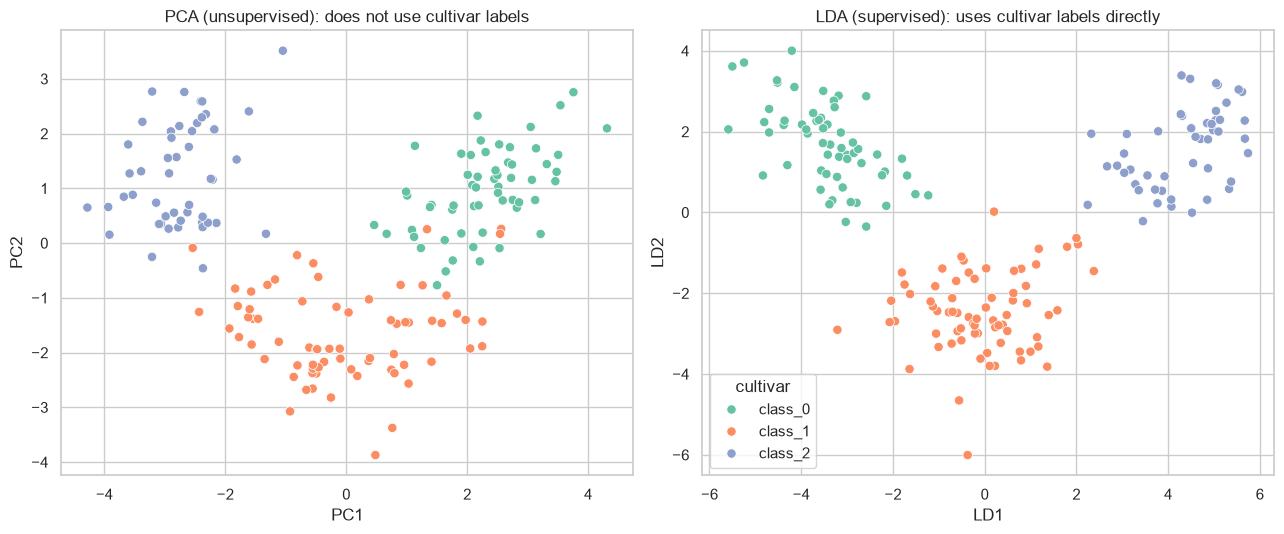

In [7]:
lda = LinearDiscriminantAnalysis(n_components=2).fit(X_scaled, y)
lda_scores = lda.transform(X_scaled)
lda_df = pd.DataFrame(lda_scores, columns=["LD1", "LD2"])
lda_df["cultivar"] = df["cultivar"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sns.scatterplot(data=scores_df, x="PC1", y="PC2", hue="cultivar", palette="Set2", s=45, ax=axes[0], legend=False)
axes[0].set_title("PCA (unsupervised): does not use cultivar labels")

sns.scatterplot(data=lda_df, x="LD1", y="LD2", hue="cultivar", palette="Set2", s=45, ax=axes[1])
axes[1].set_title("LDA (supervised): uses cultivar labels directly")
plt.tight_layout()
plt.show()


### Comparing the two projections

Look at the two plots above.

- Does LDA appear to separate the three cultivars more cleanly than PCA?
- Why would you expect that, given that LDA uses the class labels and PCA does not?
- When might you prefer PCA over LDA even if LDA produces cleaner-looking separation? (Hint: think about when class labels are not available.)

Write your answer in this cell.


## 7. AI interpretation audit

An AI assistant was given your explained-variance and loadings output and produced the following interpretation:

> "The first two principal components explain about 55% of the total variance, so these two components capture most of what matters in this dataset. PC1 appears to represent overall wine quality, and PC2 represents alcohol content. The remaining 11 components contain little useful information and can be discarded."


### Checkpoint 4: AI interpretation audit

Using your own PCA output (explained variance, cumulative variance, and loadings), answer briefly:

1. What part of the AI interpretation is supported by your PCA output?
2. What claim is too strong or not justified by the evidence?
3. Do the loadings support the proposed labels for PC1 ("wine quality") and PC2 ("alcohol content")?
4. Is retaining two components clearly the best choice? Why or why not?
5. What information could be lost by discarding the remaining components?

Write your answer in this cell.


## 8. Your turn: test a different choice

Earlier, you interpreted PC1 and PC2 using only the first two components. Now check whether that interpretation still looks reasonable once you account for more of the variance.


In [8]:
# Decide how many components you would need to reach 90% of the variance
# (use the printout from section 3), then refit PCA with that many components
# and re-examine whether PC1/PC2 alone told the full story.

n_components_alt = n_for_90  # the number of components needed for ~90% (computed above)

pca_alt = PCA(n_components=n_components_alt).fit(X_scaled)
print(f"With {n_components_alt} components, cumulative explained variance is "
      f"{np.cumsum(pca_alt.explained_variance_ratio_)[-1]*100:.1f}%.")


With 8 components, cumulative explained variance is 92.0%.


### Reflection

Write 2–4 sentences:

- Does your checkpoint 3 interpretation of PC1/PC2 still seem reasonable now that you know they only capture part of the total variance?
- What would you want to check before trusting a two-component interpretation for a real decision?


## Using AI assistance

You may use an AI assistant in this activity to ask what PCA output means, investigate why scaling matters, compare possible interpretations of loadings, or question a proposed component-retention decision. AI can help you think through these questions, but you are responsible for validating any claim against your own explained variance, scree plot, and loadings — as you practiced in the audit above.


## Final reflection

Write a short conclusion that answers this question:

When would you reach for PCA, when would you reach for LDA, and what evidence would you look at to decide how many components or directions to keep in each case?

Your answer should mention at least: the role of class labels, explained variance, and interpretation caution.
